# LENDING CLUB

# MODELAGEM DA PROBABILIDADE DE DEFAULT

# 1. IMPORTANDO BIBLIOTECAS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

import warnings
warnings.filterwarnings('ignore')

# 2. CONJUNTO DE DADOS

In [2]:
# Carrega o dataframe pré-processado (saída do notebook 01)
df = pd.read_parquet('dados/loan_data_preprocessado.parquet')
print(f'Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}')
df.head()

Linhas: 241,712 | Colunas: 37


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,mths_since_earliest_cr_line,default,mths_since_last_delinq_missing,tot_coll_amt_missing,tot_cur_bal_missing,total_rev_hi_lim_missing,parcela_renda,emprestimo_renda
94,4000,4000,36,7.4300,124.3100,A,A2,0,RENT,40000.0000,Not Verified,2007-08-01,educational,NJ,3.4500,0.0000,0.0000,0.0000,2.0000,0.0000,330,11.0000,4.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,181,1,0,1,1,1,0.0373,0.1000
96,2000,2000,36,8.7000,63.3200,B,B1,0,RENT,70000.0000,Not Verified,2007-08-01,credit_card,NY,6.0700,0.0000,1.0000,24.0000,13.0000,0.0000,5967,19.8000,17.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,208,1,0,1,1,1,0.0109,0.0286
109,4000,4000,36,10.9100,130.7900,C,C3,1,RENT,18000.0000,Not Verified,2007-08-01,car,VA,18.0000,0.0000,1.0000,0.0000,4.0000,0.0000,5533,79.6000,5.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,196,1,0,1,1,1,0.0872,0.2222
110,15000,15000,36,12.1700,499.4500,D,D2,1,MORTGAGE,83200.0000,Not Verified,2007-08-01,credit_card,WI,17.0200,0.0000,5.0000,73.0000,14.0000,0.0000,37570,59.5000,37.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,266,1,0,1,1,1,0.0720,0.1803
111,3000,3000,36,7.7500,93.6700,A,A3,9,OWN,50000.0000,Not Verified,2007-08-01,vacation,WA,5.3500,0.0000,0.0000,0.0000,17.0000,0.0000,21050,0.7000,29.0000,f,0.0000,0.0000,0.0000,0.0000,0.0000,399,1,0,1,1,1,0.0225,0.0600


# 3. DIVISÃO TREINO-TESTE (OUT-OF-TIME)

Em problemas de crédito, a divisão entre treino e teste é feita de forma temporal (*out-of-time*), e não aleatória. O modelo é treinado com os empréstimos mais antigos e avaliado nos mais recentes, reproduzindo a situação real de uso: prever o comportamento de tomadores futuros a partir de dados do passado. Como os dados já estão ordenados cronologicamente por `issue_d`, utilizamos os primeiros 80% das observações para treino e os 20% finais para teste.

In [3]:
# Divisão out-of-time: 80% mais antigos para treino, 20% mais recentes para teste
# (o dataframe já está ordenado por issue_d, feito no notebook 01)
ponto_corte = int(len(df) * 0.80)

train = df.iloc[:ponto_corte].copy()
test = df.iloc[ponto_corte:].copy()

print(f'Treino: {train.shape[0]:,} linhas | {train["issue_d"].min().date()} a {train["issue_d"].max().date()}')
print(f'Teste:  {test.shape[0]:,} linhas | {test["issue_d"].min().date()} a {test["issue_d"].max().date()}')

Treino: 193,369 linhas | 2007-08-01 a 2014-05-01
Teste:  48,343 linhas | 2014-05-01 a 2014-12-01


In [4]:
# Distribuição do alvo em treino e teste (1 = adimplente, 0 = inadimplente)
dist_train = train['default'].value_counts(normalize=True).sort_index() * 100
dist_test = test['default'].value_counts(normalize=True).sort_index() * 100

comparacao = pd.DataFrame({
    'treino (%)': dist_train.round(2),
    'teste (%)': dist_test.round(2)
})
comparacao.index = ['Inadimplente (0)', 'Adimplente (1)']
print(comparacao)
print()
print(f'Taxa de default no treino: {(train["default"]==0).mean()*100:.2f}%')
print(f'Taxa de default no teste:  {(test["default"]==0).mean()*100:.2f}%')

                  treino (%)  teste (%)
Inadimplente (0)     19.8800    25.7500
Adimplente (1)       80.1200    74.2500

Taxa de default no treino: 19.88%
Taxa de default no teste:  25.75%


In [5]:
# Taxa de default por mês de emissão (issue_d)
default_mensal = (
    df.groupby('issue_d')
    .agg(total=('default', 'size'),
         inadimplentes=('default', lambda x: (x == 0).sum()))
)
default_mensal['taxa_default'] = default_mensal['inadimplentes'] / default_mensal['total'] * 100

# Data da fronteira treino/teste
data_corte = train['issue_d'].max()
print(f'Fronteira treino/teste: {data_corte.date()}')
default_mensal.tail(15)

Fronteira treino/teste: 2014-05-01


,total,inadimplentes,taxa_default
issue_d,,,
2013-10-01,7006,1610,22.9803
2013-11-01,7040,1617,22.9688
2013-12-01,7050,1548,21.9574
2014-01-01,6969,1604,23.0162
2014-02-01,6269,1550,24.7248
2014-03-01,6686,1628,24.3494
2014-04-01,7350,1853,25.2109
2014-05-01,7045,1775,25.1952
2014-06-01,6015,1535,25.5195


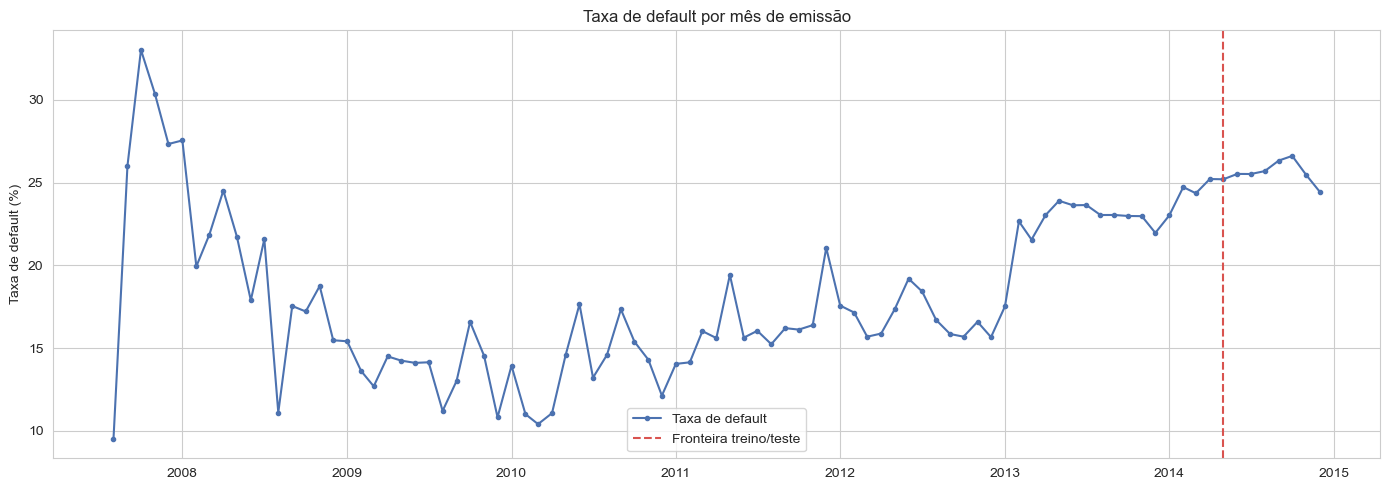

In [6]:
# Gráfico: taxa de default mensal com a fronteira treino/teste
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(default_mensal.index, default_mensal['taxa_default'],
        marker='o', markersize=3, color='#4c72b0', label='Taxa de default')
ax.axvline(data_corte, color='#d9534f', linestyle='--', label='Fronteira treino/teste')

ax.set_title('Taxa de default por mês de emissão')
ax.set_xlabel('')
ax.set_ylabel('Taxa de default (%)')
ax.legend()
plt.tight_layout()
plt.show()

### Investigação da diferença de inadimplência entre treino e teste

A divisão out-of-time resultou em taxas de inadimplência distintas entre treino (19,88%) e teste (25,75%). Para compreender essa diferença, analisamos a taxa de default por mês de emissão ao longo de toda a série.

O gráfico revela três fases: um período inicial (2007-2008) com taxas altas e voláteis, característico do início da operação; um período intermediário estável (2009-2012), com inadimplência entre 11% e 18%; e uma elevação consistente a partir de 2013, atingindo o patamar de 24-26%, no qual se situa integralmente o conjunto de teste.

Essa elevação decorre de dois fatores. Primeiro, um efeito de maturação da carteira: como a base termina em 2014, os empréstimos originados nesse período só puderam registrar os defaults ocorridos precocemente, enquanto os contratos que seriam quitados ao longo de 36 a 60 meses ainda estariam em andamento (`Current`) e foram removidos no pré-processamento. Isso concentra defaults precoces no final da série. Segundo, uma possível flexibilização das condições de concessão no período de expansão do Lending Club.

A diferença é, portanto, uma característica real dos dados, e não um artefato do particionamento. Ela não compromete a validade do modelo, uma vez que as métricas de ordenação (KS e AUC) avaliam a capacidade de distinguir bons e maus pagadores, robusta a variações na taxa base. A diferença será considerada na análise da calibração e na interpretação dos resultados.

# 4. WEIGHT OF EVIDENCE (WoE) E INFORMATION VALUE (IV)

Antes de estimar o modelo, as variáveis são transformadas pela técnica de *Weight of Evidence* (WoE), amplamente utilizada na construção de *scorecards* de crédito. A ideia central é discretizar cada variável em faixas (categorias) e substituir cada faixa por um valor que expressa o quanto ela separa bons de maus pagadores.

## Weight of Evidence (WoE)

Para cada faixa de uma variável, o WoE é definido como:

$$WoE = \ln\left(\frac{\text{proporção de bons pagadores na faixa}}{\text{proporção de maus pagadores na faixa}}\right)$$

Onde a "proporção de bons" é o número de bons pagadores da faixa dividido pelo total de bons pagadores, e analogamente para os maus. A interpretação é direta:

- **WoE positivo**: a faixa concentra proporcionalmente mais bons pagadores que maus (menor risco).
- **WoE negativo**: a faixa concentra proporcionalmente mais maus pagadores (maior risco).
- **WoE próximo de zero**: a faixa não discrimina risco.

A transformação WoE traz vantagens para a regressão logística: lida naturalmente com variáveis categóricas e com valores ausentes (que se tornam uma faixa própria), acomoda relações não lineares entre a variável e o risco, e coloca todas as variáveis em uma escala comparável.

## Information Value (IV)

Enquanto o WoE mede o poder discriminatório de cada *faixa*, o *Information Value* (IV) resume o poder preditivo da *variável inteira* em um único número:

$$IV = \sum_{\text{faixas}} (\text{prop. de bons} - \text{prop. de maus}) \times WoE$$

O IV é usado para selecionar variáveis. Uma referência usual de interpretação é:

| IV | Poder preditivo |
|---|---|
| < 0,02 | Sem poder preditivo |
| 0,02 – 0,10 | Fraco |
| 0,10 – 0,30 | Médio |
| 0,30 – 0,50 | Forte |
| > 0,50 | Muito forte (verificar sobreajuste) |

Variáveis com IV muito baixo são descartadas por não contribuírem para o modelo; variáveis com IV muito alto devem ser

Para ilustrar o cálculo, aplicamos a técnica a uma variável categórica (`grade`), que não requer discretização prévia. Os valores são calculados **apenas sobre o conjunto de treino**, evitando vazamento de informação do teste.

In [7]:
def calcular_woe_iv(dados, feature, alvo='default'):
    """
    Calcula WoE por faixa e IV total de uma variável.
    Convenção: alvo=1 (bom/adimplente), alvo=0 (mau/inadimplente).
    WoE = ln(prop_bons / prop_maus).
    """
    g = dados.groupby(feature, observed=True)[alvo].agg(['count', 'sum'])
    g.columns = ['total', 'bons']
    g['maus'] = g['total'] - g['bons']
    g['prop_bons'] = g['bons'] / g['bons'].sum()
    g['prop_maus'] = g['maus'] / g['maus'].sum()
    g['woe'] = np.log(g['prop_bons'] / g['prop_maus'])
    g['iv_faixa'] = (g['prop_bons'] - g['prop_maus']) * g['woe']
    g['taxa_default_%'] = g['maus'] / g['total'] * 100
    iv = g['iv_faixa'].sum()
    return g.round(4), round(iv, 4)

# Exemplo: grade (categórica, calculada só no treino)
tabela_grade, iv_grade = calcular_woe_iv(train, 'grade')
print(tabela_grade[['total', 'bons', 'maus', 'taxa_default_%', 'woe', 'iv_faixa']])
print(f'\nIV de grade: {iv_grade}')

       total   bons   maus  taxa_default_%     woe  iv_faixa
grade                                                       
A      33503  31112   2391          7.1367  1.1720    0.1625
B      61687  52705   8982         14.5606  0.3757    0.0400
C      48257  37370  10887         22.5605 -0.1605    0.0067
D      29671  21140   8531         28.7520 -0.4864    0.0416
E      13210   8482   4728         35.7911 -0.8094    0.0552
F       5620   3297   2323         41.3345 -1.0437    0.0409
G       1421    822    599         42.1534 -1.0774    0.0111

IV de grade: 0.358


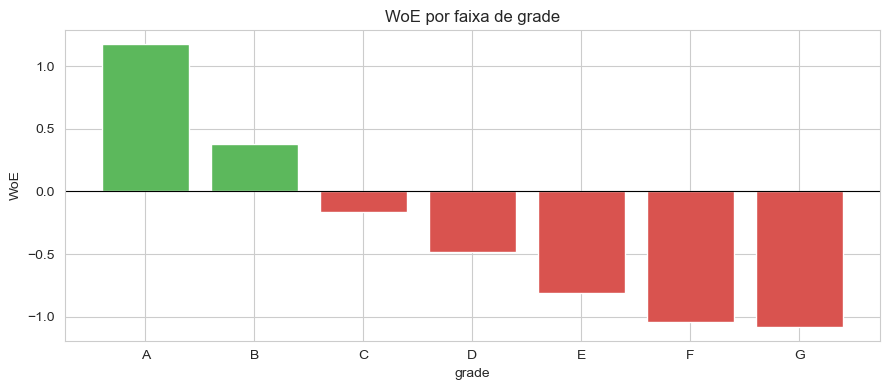

In [8]:
# Visualização do WoE por faixa de grade
plt.figure(figsize=(9, 4))
plt.bar(tabela_grade.index.astype(str), tabela_grade['woe'],
        color=['#5cb85c' if w > 0 else '#d9534f' for w in tabela_grade['woe']])
plt.axhline(0, color='black', linewidth=0.8)
plt.title('WoE por faixa de grade')
plt.xlabel('grade')
plt.ylabel('WoE')
plt.tight_layout()
plt.show()

O `grade` apresenta WoE perfeitamente monotônico: decresce de +1,17 (grade A) a -1,08 (grade G), acompanhando o aumento da taxa de inadimplência (de 7% a 42%). Com IV de 0,358, é uma variável de forte poder preditivo. Esse comportamento confirma que a classificação de risco do Lending Club ordena adequadamente os tomadores.

# 5. SELEÇÃO DE VARIÁVEIS POR INFORMATION VALUE

Antes de discretizar as variáveis com detalhe, calculamos o Information Value (IV) de cada candidata para identificar as mais preditivas. Esse passo evita investir esforço em variáveis sem poder discriminatório. A variável `addr_state` (estado do tomador) foi excluída por decisão metodológica: o uso da localização geográfica na concessão de crédito pode introduzir viés discriminatório contra determinadas regiões, o que é indesejável em um modelo responsável.

In [9]:
# Variáveis candidatas (addr_state excluída por risco de viés geográfico)
alvo = 'default'
excluir = [alvo, 'issue_d', 'addr_state']

categoricas = [c for c in train.select_dtypes(include=['object', 'category', 'string']).columns
               if c not in excluir]
numericas = [c for c in train.select_dtypes(include=[np.number]).columns
             if c not in excluir]

# IV de cada variável (numéricas discretizadas por decis, categóricas diretas)
resultados = []
tmp = train.copy()
for col in numericas:
    try:
        tmp['_bin'] = pd.qcut(train[col], q=10, duplicates='drop')
        _, iv = calcular_woe_iv(tmp, '_bin')
    except Exception:
        iv = np.nan
    resultados.append(('numérica', col, iv))
for col in categoricas:
    _, iv = calcular_woe_iv(train, col)
    resultados.append(('categórica', col, iv))

tabela_iv = (pd.DataFrame(resultados, columns=['tipo', 'variavel', 'IV'])
             .sort_values('IV', ascending=False)
             .reset_index(drop=True))
tabela_iv

,tipo,variavel,IV
0,categórica,sub_grade,0.3884
1,numérica,int_rate,0.3805
2,categórica,grade,0.3580
3,numérica,emprestimo_renda,0.1421
4,numérica,parcela_renda,0.1136
5,numérica,dti,0.0704
6,numérica,revol_util,0.0596
7,numérica,annual_inc,0.0482
8,numérica,tot_cur_bal,0.0425
9,categórica,verification_status,0.0363


Aplicamos um corte de IV ≥ 0,02 para selecionar as variáveis. Esse limiar corresponde à fronteira de "sem poder preditivo" adotada na Seção 4, descartando variáveis que praticamente não discriminam risco, incluindo as indicadoras de ausência (cujo IV resultou nulo, pois o sinal da ausência já é capturado pela discretização das próprias variáveis) e as variáveis quase constantes identificadas na análise exploratória.

In [11]:
# Corte de seleção: IV >= 0.02
LIMIAR_IV = 0.02
selecionadas = tabela_iv[tabela_iv['IV'] >= LIMIAR_IV]['variavel'].tolist()

# Inclusão manual por relevância de domínio (IV = 0.0156, logo abaixo do corte)
if 'inq_last_6mths' not in selecionadas:
    selecionadas.append('inq_last_6mths')

print(f'Variáveis selecionadas ({len(selecionadas)}):')
for v in selecionadas:
    print(f'  {v}')

Variáveis selecionadas (16):
  sub_grade
  int_rate
  grade
  emprestimo_renda
  parcela_renda
  dti
  revol_util
  annual_inc
  tot_cur_bal
  verification_status
  funded_amnt
  loan_amnt
  purpose
  total_rev_hi_lim
  installment
  inq_last_6mths


Além das variáveis com IV ≥ 0,02, incluímos manualmente `inq_last_6mths` (número de consultas de crédito nos últimos seis meses). Embora seu IV (0,0156) esteja ligeiramente abaixo do limiar, trata-se de um indicador classicamente relevante em risco de crédito: um número elevado de consultas recentes sinaliza que o tomador está buscando crédito em múltiplas instituições, comportamento associado a maior risco. A inclusão é, portanto, justificada por conhecimento de domínio.

### Tratamento de redundância: variáveis de risco

As variáveis `grade`, `sub_grade` e `int_rate` representam, essencialmente, a mesma informação: o Lending Club atribui uma classificação de risco (`grade`), refina-a em subclasses (`sub_grade`) e define a taxa de juros (`int_rate`) a partir dessa classificação. Isso se reflete tanto na forte correlação observada na análise exploratória quanto nos valores de IV praticamente idênticos das três (entre 0,358 e 0,388). Manter as três no modelo introduziria multicolinearidade sem agregar poder preditivo.

Optou-se por manter apenas `grade`, descartando `sub_grade` e `int_rate`, pelos seguintes motivos: `grade` possui apenas sete categorias já ordenadas por risco, o que dispensa agrupamento adicional e favorece a interpretabilidade do scorecard; seu IV é praticamente equivalente ao das demais; e, conceitualmente, representa a avaliação de risco original da instituição, da qual as outras duas derivam.

In [12]:
# Remove sub_grade e int_rate: redundantes com grade (mesma informação de risco)
for v in ['sub_grade', 'int_rate']:
    if v in selecionadas:
        selecionadas.remove(v)

print(f'Após tratar redundância de risco ({len(selecionadas)} variáveis):')
for v in selecionadas:
    print(f'  {v}')

Após tratar redundância de risco (14 variáveis):
  grade
  emprestimo_renda
  parcela_renda
  dti
  revol_util
  annual_inc
  tot_cur_bal
  verification_status
  funded_amnt
  loan_amnt
  purpose
  total_rev_hi_lim
  installment
  inq_last_6mths


### Tratamento de redundância: variáveis de valor

As variáveis `loan_amnt`, `funded_amnt` e `installment` são altamente correlacionadas entre si (acima de 0,95, conforme a análise exploratória), pois representam o valor do empréstimo e sua parcela, que dela deriva. Além disso, a informação de valor foi incorporada de forma mais rica às variáveis criadas na engenharia de atributos: `emprestimo_renda` (derivada de `loan_amnt`) e `parcela_renda` (derivada de `installment`), que relativizam o valor pela renda do tomador, medindo capacidade de pagamento.

Essas razões apresentam poder preditivo substancialmente maior que as variáveis brutas (IV de 0,142 e 0,114, contra 0,032 e 0,022). Optou-se, portanto, por descartar as três variáveis de valor brutas, mantendo apenas as razões, que capturam a mesma informação de forma mais discriminante e sem redundância.

In [13]:
# Remove as variáveis de valor brutas: redundantes entre si e já incorporadas
# de forma relativizada em emprestimo_renda e parcela_renda
for v in ['funded_amnt', 'loan_amnt', 'installment']:
    if v in selecionadas:
        selecionadas.remove(v)

print(f'Variáveis finais selecionadas ({len(selecionadas)}):')
for v in selecionadas:
    print(f'  {v}')

Variáveis finais selecionadas (11):
  grade
  emprestimo_renda
  parcela_renda
  dti
  revol_util
  annual_inc
  tot_cur_bal
  verification_status
  purpose
  total_rev_hi_lim
  inq_last_6mths


# 6. DISCRETIZAÇÃO E CÁLCULO DE WoE

As variáveis numéricas selecionadas são discretizadas em faixas por decis (quantis de igual frequência) e, em seguida, transformadas em WoE. Para cada variável, verificamos se o WoE resultante é monotônico, ou seja, se o risco varia de forma consistente entre faixas adjacentes. Variáveis não monotônicas recebem ajuste manual no agrupamento das faixas. As variáveis categóricas não requerem discretização.

In [14]:
def eh_monotonica(woes):
    d = np.diff(woes)
    return bool(np.all(d <= 0) or np.all(d >= 0))

# Numéricas selecionadas
num_selecionadas = ['emprestimo_renda', 'parcela_renda', 'dti', 'revol_util',
                    'annual_inc', 'tot_cur_bal', 'total_rev_hi_lim', 'inq_last_6mths']

# Diagnóstico: discretiza por decis e verifica monotonicidade
print(f'{"variável":<20}{"n_bins":<8}{"IV":<10}{"monotônica"}')
print('-' * 50)
for col in num_selecionadas:
    tmp = train.copy()
    tmp['_bin'] = pd.qcut(train[col], q=10, duplicates='drop')
    tab, iv = calcular_woe_iv(tmp, '_bin')
    print(f'{col:<20}{len(tab):<8}{iv:<10}{eh_monotonica(tab["woe"].values)}')

variável            n_bins  IV        monotônica
--------------------------------------------------
emprestimo_renda    10      0.1421    True
parcela_renda       10      0.1136    True
dti                 10      0.0704    True
revol_util          10      0.0596    True
annual_inc          10      0.0482    True
tot_cur_bal         7       0.0425    False
total_rev_hi_lim    7       0.0258    False
inq_last_6mths      3       0.0156    True


### Ajuste de `tot_cur_bal`

A variável `tot_cur_bal` apresentou 34,4% de valores iguais a zero (correspondentes às ausências preenchidas no pré-processamento) e WoE não monotônico na discretização por decis. O valor zero representa ausência de informação, e não saldo baixo, sendo portanto isolado em uma faixa própria. As demais observações foram discretizadas em faixas que garantem monotonicidade do WoE, agrupando-se as duas faixas iniciais, de risco praticamente equivalente. Observa-se que a faixa "zero" apresenta WoE positivo, indicando menor risco relativo, possivelmente associado a tomadores com menor uso de crédito.

In [15]:
# tot_cur_bal: zero isolado (ausência) + faixas monotônicas para o restante
bins_tcb = [-1, 0, 37148, 78981, 164067, 260300, np.inf]
labels_tcb = ['zero', 'ate_37k', '37k_79k', '79k_164k', '164k_260k', '260k+']
train['tot_cur_bal_bin'] = pd.cut(train['tot_cur_bal'], bins=bins_tcb, labels=labels_tcb)

tab_tcb, iv_tcb = calcular_woe_iv(train, 'tot_cur_bal_bin')
print(tab_tcb[['total', 'maus', 'woe']].round(4).reindex(labels_tcb))
print(f'\nIV: {iv_tcb}')

                 total   maus     woe
tot_cur_bal_bin                      
zero             66483  10873  0.2382
ate_37k          42296  10243 -0.2530
37k_79k          21148   5101 -0.2478
79k_164k         21147   4714 -0.1451
164k_260k        21147   4164  0.0119
260k+            21148   3346  0.2777

IV: 0.0506


### Ajuste de `total_rev_hi_lim`

Assim como `tot_cur_bal`, a variável `total_rev_hi_lim` apresentou 34,4% de valores iguais a zero (ausências preenchidas no pré-processamento) e WoE não monotônico. Aplicamos o mesmo tratamento: o valor zero é isolado em faixa própria e o restante é discretizado por quantis. As faixas não nulas resultam monotônicas sem necessidade de agrupamento adicional. A faixa "zero" novamente apresenta WoE positivo, coerente com o observado em `tot_cur_bal`.

In [16]:
# total_rev_hi_lim: zero isolado + quantis para o restante
bins_trhl = [-1, 0, 11700, 18300, 26600, 40507, np.inf]
labels_trhl = ['zero', 'ate_11.7k', '11.7k_18.3k', '18.3k_26.6k', '26.6k_40.5k', '40.5k+']
train['total_rev_hi_lim_bin'] = pd.cut(train['total_rev_hi_lim'], bins=bins_trhl, labels=labels_trhl)

tab_trhl, iv_trhl = calcular_woe_iv(train, 'total_rev_hi_lim_bin')
print(tab_trhl[['total', 'maus', 'woe']].round(4).reindex(labels_trhl))
print(f'\nIV: {iv_trhl}')

                      total   maus     woe
total_rev_hi_lim_bin                      
zero                  66456  10865  0.2386
ate_11.7k             25552   6139 -0.2426
11.7k_18.3k           25566   5900 -0.1899
18.3k_26.6k           25134   5624 -0.1500
26.6k_40.5k           25278   5451 -0.1026
40.5k+                25383   4462  0.1513

IV: 0.0389


### Transformação WoE de treino e teste

Consolidamos a discretização e a transformação WoE das 11 variáveis selecionadas. As cinco variáveis contínuas bem comportadas são discretizadas por decis; `tot_cur_bal`, `total_rev_hi_lim` e `inq_last_6mths` usam cortes manuais definidos anteriormente. As três categóricas dispensam discretização.

Ponto central para evitar vazamento: os cortes e os valores de WoE são aprendidos **apenas no treino** e depois aplicados ao teste, sem qualquer reestimação. As bordas das faixas são estendidas ao infinito para garantir que valores do teste fora do intervalo de treino ainda sejam alocados corretamente.

In [17]:
def woe_map(tr, col_bin, alvo='default'):
    g = tr.groupby(col_bin, observed=True)[alvo].agg(['count', 'sum'])
    g.columns = ['t', 'bons']
    g['maus'] = g['t'] - g['bons']
    pb = g['bons'] / g['bons'].sum()
    pm = g['maus'] / g['maus'].sum()
    return (np.log(pb / pm)).to_dict()

# Numéricas por decis (bem comportadas)
num_qcut = ['emprestimo_renda', 'parcela_renda', 'dti', 'revol_util', 'annual_inc']

# Numéricas com cortes manuais (zeros isolados / variável discreta)
cortes_manuais = {
    'tot_cur_bal':      [-np.inf, 0, 37148, 78981, 164067, 260300, np.inf],
    'total_rev_hi_lim': [-np.inf, 0, 11700, 18300, 26600, 40507, np.inf],
    'inq_last_6mths':   [-np.inf, 0, 1, 2, np.inf],  # faixas: 0, 1, 2, 3+
}

categoricas = ['grade', 'verification_status', 'purpose']

# --- Aprende cortes e mapas WoE SOMENTE no treino ---
edges, mapas = {}, {}
for col in num_qcut:
    _, e = pd.qcut(train[col], q=10, duplicates='drop', retbins=True)
    e[0], e[-1] = -np.inf, np.inf          # estende bordas para cobrir o teste
    edges[col] = e
    train[col + '_bin'] = pd.cut(train[col], bins=e)
    mapas[col] = woe_map(train, col + '_bin')

for col, c in cortes_manuais.items():
    edges[col] = c
    train[col + '_bin'] = pd.cut(train[col], bins=c)
    mapas[col] = woe_map(train, col + '_bin')

for col in categoricas:
    mapas[col] = woe_map(train, col)

# --- Aplica ao teste usando os cortes/mapas do treino ---
todas_num = num_qcut + list(cortes_manuais)
for col in todas_num:
    test[col + '_bin'] = pd.cut(test[col], bins=edges[col])

def transformar_woe(dados):
    X = pd.DataFrame(index=dados.index)
    for col in todas_num:
        X[col] = dados[col + '_bin'].map(mapas[col])
    for col in categoricas:
        X[col] = dados[col].map(mapas[col])
    return X

X_train = transformar_woe(train)
X_test = transformar_woe(test)
y_train = train['default']
y_test = test['default']

print(f'X_train: {X_train.shape} | NaN: {X_train.isna().sum().sum()}')
print(f'X_test:  {X_test.shape} | NaN: {X_test.isna().sum().sum()}')

X_train: (193369, 11) | NaN: 0
X_test:  (48343, 11) | NaN: 0


In [18]:
X_train.head()

,emprestimo_renda,parcela_renda,dti,revol_util,annual_inc,tot_cur_bal,total_rev_hi_lim,inq_last_6mths,grade,verification_status,purpose
94,0.4085,0.3766,0.4160,0.5909,-0.2479,0.2382,0.2386,0.1436,1.1720,0.2647,-0.0852
96,0.4947,0.5268,0.4160,0.5909,0.0330,0.2382,0.2386,-0.0465,0.3757,0.2647,0.1649
109,0.0838,-0.0873,0.0036,-0.2041,-0.2810,0.2382,0.2386,-0.0465,-0.1605,0.2647,0.5152
110,0.1918,0.1440,0.0036,-0.0684,0.2297,0.2382,0.2386,-0.2917,-0.4864,0.2647,0.1649
111,0.4947,0.5268,0.4160,0.5909,-0.1068,0.2382,0.2386,0.1436,1.1720,0.2647,0.0547


In [19]:
X_test.head()

,emprestimo_renda,parcela_renda,dti,revol_util,annual_inc,tot_cur_bal,total_rev_hi_lim,inq_last_6mths,grade,verification_status,purpose
300914,0.1918,0.1440,0.0897,0.5909,0.1077,-0.2478,0.1513,0.1436,1.1720,0.2647,0.1649
300915,0.0838,0.2189,0.0897,-0.1153,0.1077,0.0119,-0.1500,0.1436,-0.4864,0.2647,-0.0623
300921,-0.6790,-0.4534,-0.0804,-0.0684,0.0330,-0.1451,-0.1500,0.1436,-0.8094,0.2647,-0.0623
300923,0.3552,0.3517,0.1601,0.0625,-0.0914,-0.2530,-0.1899,-0.0465,0.3757,0.2647,-0.0623
300924,-0.6790,-0.5033,0.2053,0.2952,-0.1587,-0.2530,-0.2426,0.1436,0.3757,0.2647,-0.0623


In [20]:
y_train.head()

94     1
96     1
109    1
110    1
111    1
Name: default, dtype: int64

In [21]:
y_test.head()

300914    1
300915    1
300921    0
300923    1
300924    0
Name: default, dtype: int64

# 7. REGRESSÃO LOGÍSTICA

Com as variáveis transformadas em WoE, estimamos o modelo de probabilidade de default por regressão logística. Utilizamos a biblioteca `statsmodels`, que fornece os p-valores dos coeficientes, permitindo avaliar a significância estatística de cada variável, prática usual na construção de scorecards. Como a variável-alvo adota a convenção `1 = adimplente`, coeficientes positivos indicam associação com menor risco.

In [22]:
# Adiciona a constante (intercepto) exigida pelo statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Estima a regressão logística
modelo = sm.Logit(y_train, X_train_sm).fit(disp=False)

# Resumo com coeficientes, p-valores e significância
print(modelo.summary())

                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:               193369
Model:                          Logit   Df Residuals:                   193357
Method:                           MLE   Df Model:                           11
Date:                Mon, 28 Sep 2026   Pseudo R-squ.:                 0.07734
Time:                        22:41:08   Log-Likelihood:                -88980.
converged:                       True   LL-Null:                       -96439.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.3969      0.006    230.097      0.000       1.385       1.409
emprestimo_renda        1.1789      0.042     28.069      0.000       1.097       1.261
parcela_renda   

### Tratamento de redundância entre as razões de renda

O modelo inicial apresentou coeficiente negativo para `parcela_renda`, contrário ao esperado na transformação WoE (em que todos os coeficientes deveriam ser positivos). A investigação revelou correlação de 0,95 entre `parcela_renda` e `emprestimo_renda`, o que era esperado: a parcela é proporcional ao valor do empréstimo, de modo que ambas as razões medem, essencialmente, o mesmo comprometimento financeiro em relação à renda. Essa multicolinearidade fez com que o modelo atribuísse sinais opostos às duas variáveis. Optou-se por manter `emprestimo_renda` (maior IV e coeficiente coerente) e remover `parcela_renda`, eliminando a redundância.

In [23]:
# Remove parcela_renda (redundante com emprestimo_renda, correlação 0.95)
X_train_final = X_train.drop(columns=['parcela_renda'])
X_test_final = X_test.drop(columns=['parcela_renda'])

# Reajusta o modelo com 10 variáveis
X_train_sm = sm.add_constant(X_train_final)
X_test_sm = sm.add_constant(X_test_final)
modelo = sm.Logit(y_train, X_train_sm).fit(disp=False)
print(modelo.summary())

                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:               193369
Model:                          Logit   Df Residuals:                   193358
Method:                           MLE   Df Model:                           10
Date:                Mon, 28 Sep 2026   Pseudo R-squ.:                 0.07591
Time:                        22:43:17   Log-Likelihood:                -89118.
converged:                       True   LL-Null:                       -96439.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.3975      0.006    230.337      0.000       1.386       1.409
emprestimo_renda        0.5437      0.017     31.097      0.000       0.509       0.578
dti             

# 8. VALIDAÇÃO DO MODELO

Avaliamos o desempenho do modelo com as métricas usuais em risco de crédito, calculadas tanto no treino quanto no teste (out-of-time) para verificar generalização:

- **AUC-ROC**: área sob a curva ROC, mede a capacidade de ordenar bons e maus pagadores.
- **Gini**: derivado do AUC (Gini = 2·AUC − 1), métrica tradicional em crédito.
- **KS (Kolmogorov-Smirnov)**: máxima separação entre as distribuições acumuladas de bons e maus pagadores.

In [24]:
# Probabilidades preditas (probabilidade de ser bom pagador, classe 1)
proba_train = modelo.predict(X_train_sm)
proba_test = modelo.predict(X_test_sm)

def metricas(y_true, proba):
    auc = roc_auc_score(y_true, proba)
    gini = 2 * auc - 1
    # KS: máxima diferença entre as acumuladas
    fpr, tpr, _ = roc_curve(y_true, proba)
    ks = np.max(np.abs(tpr - fpr))
    return auc, gini, ks

auc_tr, gini_tr, ks_tr = metricas(y_train, proba_train)
auc_te, gini_te, ks_te = metricas(y_test, proba_test)

resultados = pd.DataFrame({
    'Treino': [auc_tr, gini_tr, ks_tr],
    'Teste': [auc_te, gini_te, ks_te]
}, index=['AUC', 'Gini', 'KS']).round(4)
print(resultados)

      Treino  Teste
AUC   0.6922 0.6953
Gini  0.3843 0.3906
KS    0.2791 0.2883


O modelo apresenta desempenho consistente entre treino e teste (AUC de 0,692 e 0,695; KS de 0,279 e 0,288), indicando boa capacidade de generalização e ausência de sobreajuste. Os valores situam-se em patamar adequado para modelos de risco de crédito (KS entre 0,25 e 0,35). Cabe destacar que a proximidade entre as métricas de treino e teste confirma que a diferença na taxa de inadimplência entre os dois períodos, decorrente da remoção dos contratos em andamento, não comprometeu a capacidade discriminatória do modelo, uma vez que AUC e KS avaliam a ordenação de risco, robusta a variações na taxa base.

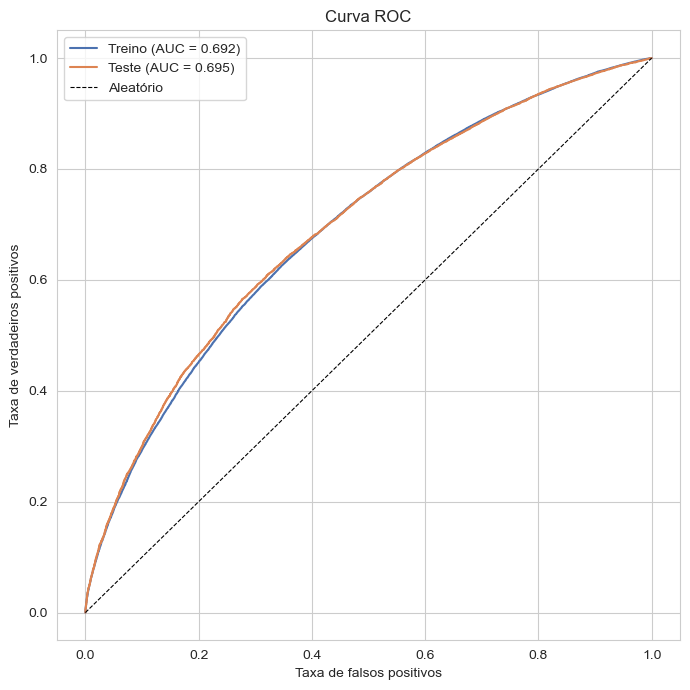

In [25]:
# Curva ROC (treino e teste)
fpr_tr, tpr_tr, _ = roc_curve(y_train, proba_train)
fpr_te, tpr_te, _ = roc_curve(y_test, proba_test)

plt.figure(figsize=(7, 7))
plt.plot(fpr_tr, tpr_tr, label=f'Treino (AUC = {auc_tr:.3f})', color='#4c72b0')
plt.plot(fpr_te, tpr_te, label=f'Teste (AUC = {auc_te:.3f})', color='#dd8452')
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Aleatório')
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.show()

# 9. SCORECARD

A probabilidade de default é convertida em um score de crédito, uma escala em que valores maiores indicam menor risco, mais intuitiva para a decisão de concessão. A transformação é linear sobre o logaritmo das odds (razão entre probabilidade de bom e de mau pagador), padrão na construção de scorecards:

$$Score = offset + fator \times \ln(odds)$$

O parâmetro PDO (Points to Double the Odds) define de quantos pontos a odds dobra, e a âncora (score base e odds base) posiciona a escala. Como a carteira apresenta risco relativamente alto, ancoramos o score na odds mediana da própria base, de modo que a escala reflita o perfil real dos tomadores.

Score: mín 388 | média 504 | máx 635


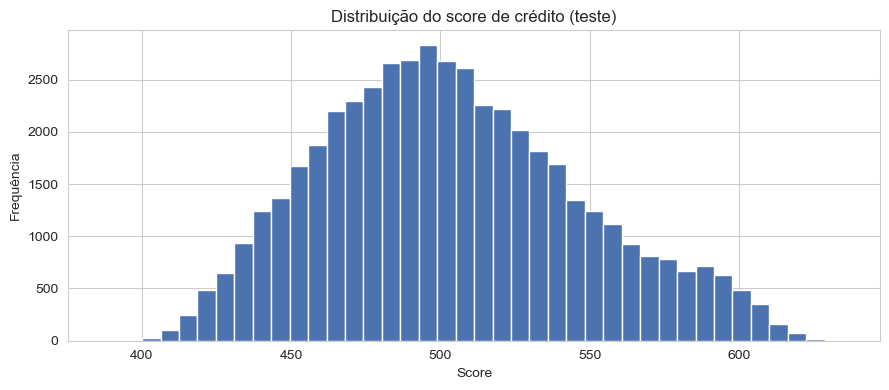

In [26]:
# PD e odds a partir do modelo
proba_bom = modelo.predict(X_test_sm)          # prob. de ser bom pagador
test['PD'] = 1 - proba_bom                       # probabilidade de default
odds = proba_bom / (1 - proba_bom)               # odds de ser bom pagador

# Parâmetros do scorecard, ancorados na carteira
PDO = 40
score_base = 500
odds_base = odds.median()

fator = PDO / np.log(2)
offset = score_base - fator * np.log(odds_base)
test['score'] = offset + fator * np.log(odds)

print(f'Score: mín {test["score"].min():.0f} | média {test["score"].mean():.0f} | máx {test["score"].max():.0f}')

# Distribuição do score
plt.figure(figsize=(9, 4))
plt.hist(test['score'], bins=40, color='#4c72b0', edgecolor='white')
plt.title('Distribuição do score de crédito (teste)')
plt.xlabel('Score')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

A distribuição do score aproxima-se de uma forma de sino, concentrada em torno de 500, com caudas menos densas nos extremos. Esse comportamento é desejável em um scorecard: a maior parte dos tomadores situa-se em uma faixa intermediária de risco, com poucos casos nos extremos de altíssimo ou baixíssimo risco. Scores maiores correspondem a menor probabilidade de default.

# 10. DEFINIÇÃO DA ELEGIBILIDADE

O ponto de corte que separa clientes elegíveis de inelegíveis é definido pela maximização da estatística KS, critério padrão em scorecards por corresponder ao ponto de melhor separação entre bons e maus pagadores. Esse corte equivale a um score mínimo de 501. Clientes com score igual ou superior são considerados elegíveis ao crédito e seguem para a etapa de otimização da carteira; os demais são reprovados nesta fase.

In [27]:
# Corte de elegibilidade pelo máximo KS (equivalente a score >= 501)
SCORE_CORTE = 501

test['elegivel'] = (test['score'] >= SCORE_CORTE).astype(int)

print(test['elegivel'].value_counts())
print(f"\nTaxa de aprovação: {test['elegivel'].mean()*100:.1f}%")

# Sanidade: a taxa de default real deve ser MENOR entre os elegíveis
print(f"\nTaxa de default real entre ELEGÍVEIS:   {(1-test.loc[test['elegivel']==1,'default']).mean()*100:.1f}%")
print(f"Taxa de default real entre INELEGÍVEIS: {(1-test.loc[test['elegivel']==0,'default']).mean()*100:.1f}%")

elegivel
0    24604
1    23739
Name: count, dtype: int64

Taxa de aprovação: 49.1%

Taxa de default real entre ELEGÍVEIS:   14.5%
Taxa de default real entre INELEGÍVEIS: 36.6%


A aplicação do corte de elegibilidade demonstra a eficácia do modelo: entre os clientes considerados elegíveis, a taxa de inadimplência real é de 14,5%, contra 36,6% entre os inelegíveis e 25,75% na base completa. Ou seja, a política de corte por score reduziria a inadimplência da carteira de 25,75% para 14,5%, aprovando cerca de 49% dos solicitantes. Esse resultado confirma que o modelo ordena adequadamente o risco e fornece uma base sólida de clientes elegíveis para a etapa de otimização.

# 11. EXPORTAÇÃO DOS CLIENTES ELEGÍVEIS

Concluída a etapa de predição, exportamos os clientes elegíveis (score ≥ 501) com as variáveis necessárias para a otimização da carteira: valor e condições do empréstimo (para o cálculo do retorno), classificação de risco e finalidade (para as restrições de diversificação), além da probabilidade de default e do score estimados. Esse conjunto é a entrada do notebook de otimização.

In [28]:
# Seleciona apenas os clientes elegíveis
elegiveis = test[test['elegivel'] == 1].copy()

# Colunas necessárias para a otimização (notebook 04)
cols_otimizacao = [
    'loan_amnt', 'int_rate', 'term', 'installment',   # cálculo do retorno
    'grade', 'purpose',                                # restrições de diversificação
    'annual_inc',                                      # contexto
    'PD', 'score',                                     # saídas do modelo
    'default'                                          # desfecho real (para validação posterior)
]
elegiveis_export = elegiveis[cols_otimizacao].reset_index(drop=True)

# Salva para o notebook de otimização
elegiveis_export.to_parquet('dados/clientes_elegiveis.parquet')

print(f'Clientes elegíveis exportados: {elegiveis_export.shape[0]:,} linhas × {elegiveis_export.shape[1]} colunas')
elegiveis_export.head()

Clientes elegíveis exportados: 23,739 linhas × 10 colunas


,loan_amnt,int_rate,term,installment,grade,purpose,annual_inc,PD,score,default
0,13000,6.0300,36,395.6700,A,credit_card,75000.0000,0.0550,590.6108,1
1,8000,9.1700,36,255.0400,B,debt_consolidation,60000.0000,0.1411,530.7204,1
2,19300,11.6700,36,638.0000,B,debt_consolidation,43000.0000,0.2066,504.1375,0
3,23000,12.4900,36,769.3300,B,debt_consolidation,109200.0000,0.1278,537.3096,1
4,9000,11.6700,36,297.5200,B,debt_consolidation,30000.0000,0.2149,501.2550,1
